In [2]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 确保 src/ 包可被导入
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)

from config import COAL_TYPES, TRAIN_DIR, TEST_DIR, AUX_COLS, ALPHAS
from src.data   import load_labels, load_coal_spectra
from src.submit import pack_submission
from src.model import get_cv_splits
from src.features import build_feature_matrix


In [3]:
label_map, aux_map = load_labels()
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)

y          = train_data['targets']
aux        = train_data['aux']
n_batches = train_data['n_batches']
groups  = train_data['groups']

splits = get_cv_splits(groups, n_batches)
X_spec, scaler_spec, pca, scaler_hand = build_feature_matrix(
        train_data, n_batches, fit=True)

In [4]:
from sklearn.linear_model import RidgeCV

# function for compute stage 2
def stage2(X_s2, y, groups, splits):
    oof_batch_preds, oof_batch_true, batch_rmses = [], [], []

    for tr_idx, val_idx in splits:
        m2 = RidgeCV(alphas=ALPHAS)
        m2.fit(X_s2[tr_idx], y[tr_idx])
        val_pred   = m2.predict(X_s2[val_idx])
        val_groups = groups[val_idx]

        fold_se = []
        for bg in np.unique(val_groups):
            mask   = val_groups == bg
            true_q = float(y[val_idx][mask][0])
            pred_q = float(np.median(val_pred[mask]))
            oof_batch_preds.append(pred_q)
            oof_batch_true.append(true_q)
            fold_se.append((true_q - pred_q) ** 2)
        batch_rmses.append(float(np.sqrt(np.mean(fold_se))))

    cv_rmse_raw = float(np.mean(batch_rmses))
    print(f"Average RMSE across the batch: {cv_rmse_raw: .2f}")

In [ ]:
# Predicting outcomes directly from PCA + hand features
print("PCA + handcrafted → calorific value")
print("---")
stage2(X_spec, y, groups, splits)

PCA + handcrafted → calorific value
---
Average RMSE across the batch:  339.45


In [8]:
aux_models        = {}
predicted_aux_oof = np.zeros_like(aux, dtype=np.float32)
for col_idx, col_name in enumerate(AUX_COLS):
    y_aux = aux[:, col_idx]

    # 辅助指标有缺失时退化为用均值填充
    if np.isnan(y_aux).any():
        predicted_aux_oof[:, idx] = float(np.nanmean(y_aux))
        aux_models[col_name] = None
        continue

    m = RidgeCV(alphas=ALPHAS)
    oof = np.zeros(len(y_aux))
    # Foldwise model for intermediate prediction
    for tr_idx, val_idx in splits:
        m.fit(X_spec[tr_idx], y_aux[tr_idx])
        oof[val_idx] = m.predict(X_spec[val_idx])
    predicted_aux_oof[:, col_idx] = oof

    m.fit(X_spec, y_aux)   # 全量重新拟合，存入 aux_models 供推理用
    aux_models[col_name] = m

In [11]:
from sklearn.preprocessing import StandardScaler
X_s2      = np.hstack([X_spec, predicted_aux_oof])
scaler_s2 = StandardScaler()
X_s2      = scaler_s2.fit_transform(np.nan_to_num(X_s2))

In [16]:
# Baseline model
print("PCA + handcrafted + predicted aux variables → calorific value")
print("---")
stage2(X_s2, y, groups, splits)

PCA + handcrafted + predicted aux variables → calorific value
---
Average RMSE across the batch:  158.10


In [ ]:
# True aux -> calorific values
_, unique_indices = np.unique(groups, return_index=True)
aux_batch = aux[unique_indices]
y_batch = y[unique_indices]

In [28]:
from sklearn.model_selection import KFold
k_fold = KFold()
y_pred = np.zeros(len(y_batch), dtype=np.float32)

for tr_idx, val_idx in k_fold.split(aux_batch):
    m = RidgeCV(alphas=ALPHAS)
    m.fit(aux_batch[tr_idx], y_batch[tr_idx])
    y_pred[val_idx] = m.predict(aux_batch[val_idx])

rmse = np.sqrt(np.mean((y_pred - y_batch) ** 2))
print("True aux variables → calorific value")
print("---")
print(f"Average RMSE across the batch: {rmse: .2f}")

True aux variables → calorific value
---
Average RMSE across the batch:  65.49


In [29]:
print("Predicted aux variables → calorific value")
print("---")
stage2(predicted_aux_oof, y, groups, splits)

Predicted aux variables → calorific value
---
Average RMSE across the batch:  384.94


Some remarks:
- True aux variables make nearly perfect prediction, which means that if we can do Stage 1 perfectly, we nail it
- PCA + hand feats and predicted aux variables individually perform badly, but when they are combined, there are some dramatic improvements. This is probably because each lack important information the other has
- We might want to focus more on extracting more useful information from the spec data

## Inspecting the coefficients of Stage 1 Ridge

In [30]:
aux_models = {}
for col_idx, col_name in enumerate(AUX_COLS):
    y_aux = aux[:, col_idx]
    m = RidgeCV(alphas=ALPHAS)
    m.fit(X_spec, y_aux)   # 全量重新拟合，存入 aux_models 供推理用
    aux_models[col_name] = m


In [58]:
model_coef = {}

for aux in aux_models.keys():
    model = aux_models[aux]
    # Revert the second standardisation
    coef = model.coef_ / scaler_hand.scale_
    # split into two parts
    coef_pca = coef[:pca.n_components_]
    coef_hand = coef[pca.n_components_:]
    # Revert back to the coefficients on the wavelength
    coef_wave = pca.components_.T @ coef_pca
    # Undo the standardization
    coef_wave = coef_wave / scaler_spec.scale_

    model_coef[aux] = (coef_wave, coef_hand)

In [55]:
list(model_coef.keys())

['全水分', '灰分', '氢', '硫']

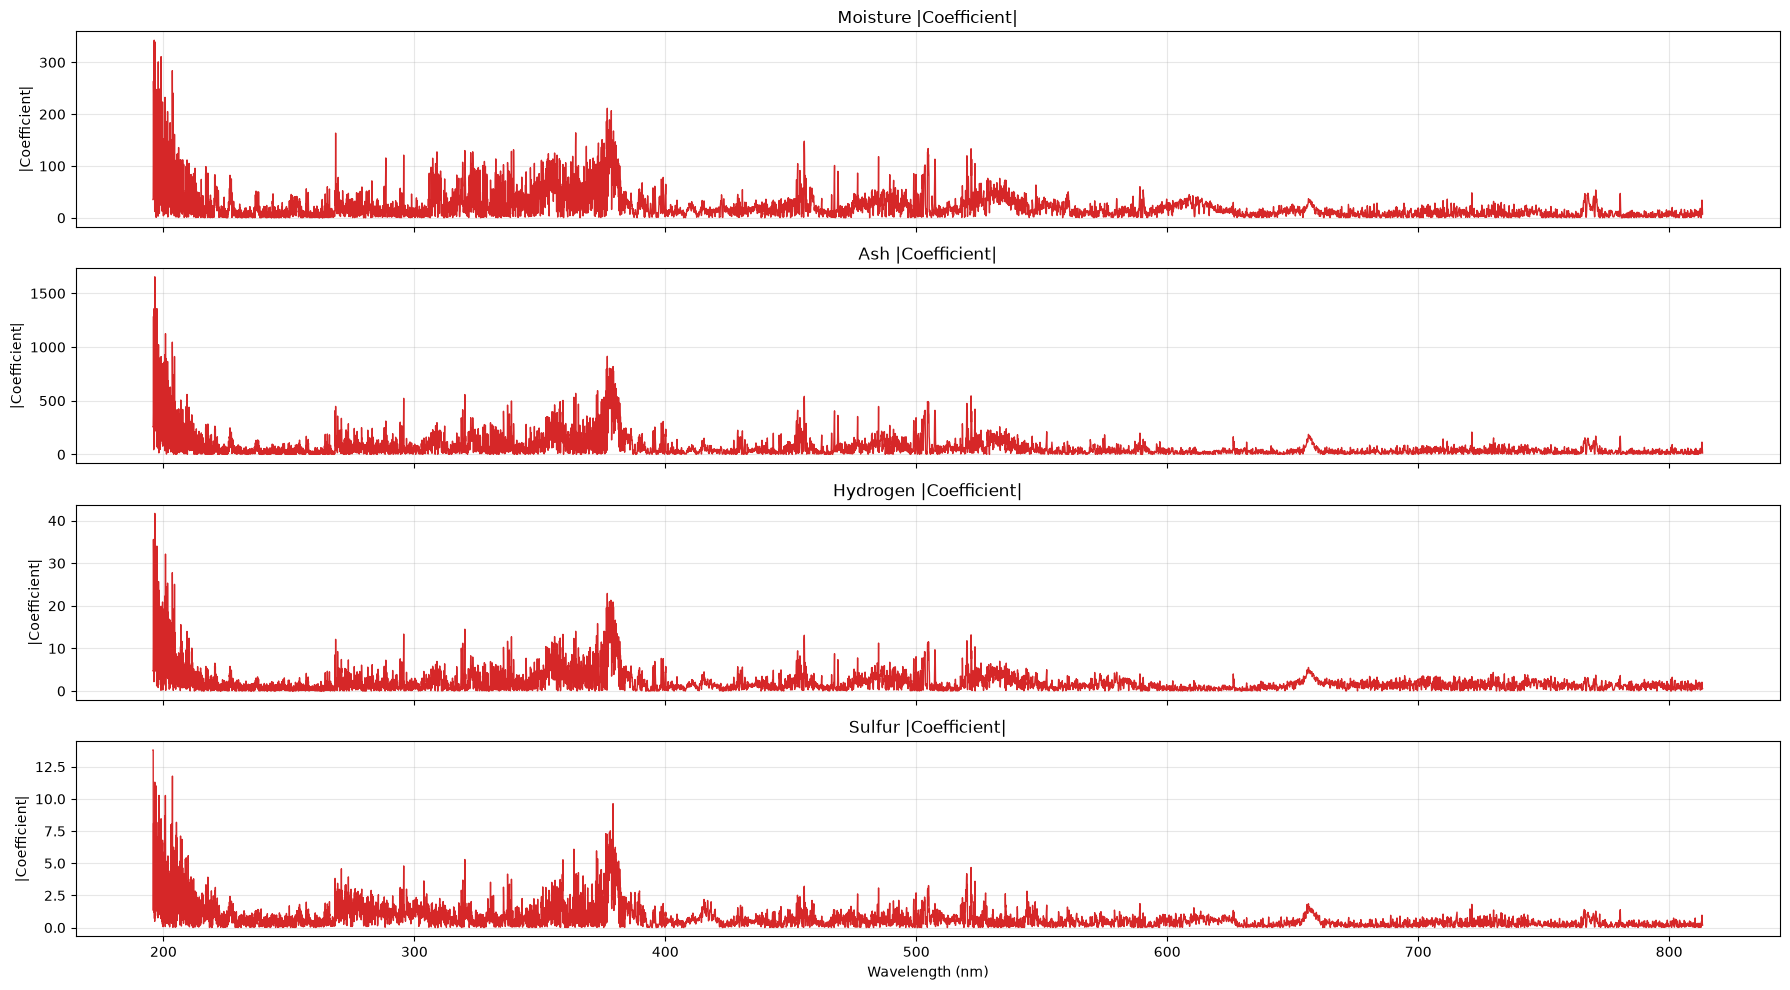

In [ ]:
wavelength = train_data['spectra'][0][0]
hand_length = [i for i in range(len(model_coef[AUX_COLS[0]][1]))]

import matplotlib.pyplot as plt

titles = ["Moisture", "Ash", "Hydrogen", "Sulfur"]

fig, axes = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

for idx, title in enumerate(AUX_COLS):

    coef = model_coef[title]

    axes[idx].plot(wavelength, np.abs(coef[0]), color='tab:red', lw=1.0)

    axes[idx].set_title(f"{titles[idx]} |Coefficient|")
    axes[idx].set_ylabel("|Coefficient|")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()

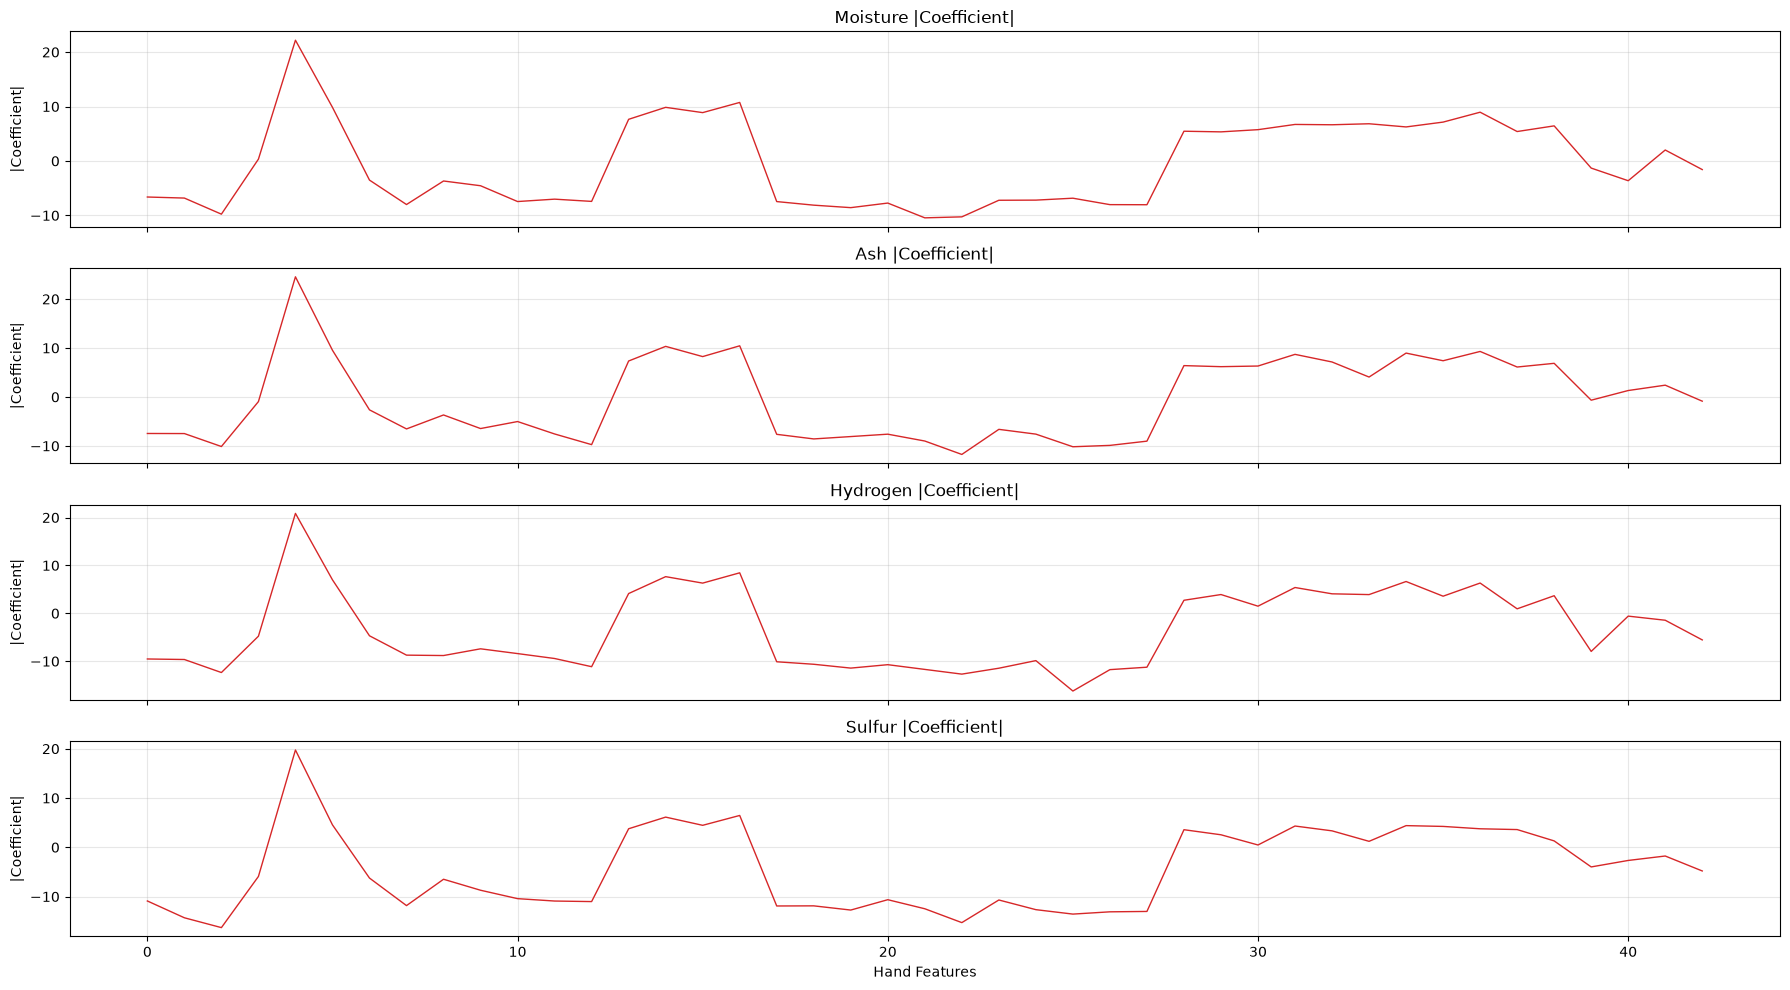

In [71]:
fig, axes = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

for idx, title in enumerate(AUX_COLS):

    coef = model_coef[title]

    axes[idx].plot(hand_length, np.log(np.abs(coef[1])), color='tab:red', lw=1.0)

    axes[idx].set_title(f"{titles[idx]} |Coefficient|")
    axes[idx].set_ylabel("|Coefficient|")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("Hand Features")

plt.tight_layout()
plt.show()

In [ ]:
moisture_abs_coef_hand = np.abs(model_coef[AUX_COLS[0]][1])


array([1.33283985e-03, 1.09828765e-03, 5.71957401e-05, 1.39849688e+00,
       4.27645929e+09, 1.89415366e+04, 2.97855977e-02, 3.35297703e-04,
       2.52445682e-02, 1.05720445e-02, 5.80319964e-04, 8.99839984e-04,
       5.96092345e-04, 2.10075514e+03, 1.89288786e+04, 7.18213404e+03,
       4.65893149e+04, 5.76243394e-04, 2.98395118e-04, 1.89228268e-04,
       4.38570828e-04, 2.90500002e-05, 3.48590635e-05, 7.33784417e-04,
       7.52938822e-04, 1.07160438e-03, 3.28771647e-04, 3.23132495e-04,
       2.35474448e+02, 2.09427540e+02, 3.13456354e+02, 8.19043682e+02,
       7.71664354e+02, 9.28540430e+02, 5.18130363e+02, 1.25982841e+03,
       7.74912218e+03, 2.22720575e+02, 6.29387290e+02, 2.70676609e-01,
       2.65582304e-02, 7.47758545e+00, 2.05577346e-01])

In [90]:
max_idx = np.where(moisture_abs_coef_hand == np.max(moisture_abs_coef_hand))[0].item()
max_idx

4

Remarks:
- The two observations are that 1) The spectral data predicts the four auxiliary variables similarly, and 2) One global statistics, which is the mean intensity after normalisation dominates the prediction
- This might suggest that the model is learning a latent variable that predict all four auxiliary variables

We now would like to investigate several issues. The first is that if the normalisation by total intensity makes the `inorm_mean` has too small a variance.

In [98]:
inorm_mean = np.nan_to_num(train_data['stats'][:,max_idx], nan=0.0, posinf=0.0, neginf=0.0)
inorm_mean.shape

(140,)

In [101]:
np.mean(inorm_mean), np.std(inorm_mean)

(np.float32(0.00013689254), np.float32(5.500107e-12))

This is it. This is variable is essentially constant. Let's try to remove it.

In [131]:
mask = moisture_abs_coef_hand == np.max(moisture_abs_coef_hand)
mask = np.hstack([np.zeros(pca.n_components_, dtype=bool), mask])
X_spec_removed = np.delete(X_spec, mask, axis = 1)

In [141]:
np.std(np.nan_to_num(train_data['stats'], nan=0.0, posinf=0.0, neginf=0.0), axis = 0) < 1e-3

array([False, False, False, False,  True,  True, False, False, False,
       False, False, False, False,  True,  True,  True,  True])

It turns out that removing only the `inten_norm` hurts the performance while removing all of them brings the RMSE back.